<h2>SGD and NN</h2>

In [1]:
%matplotlib notebook

#<GRADED>
import numpy as np
from numpy.matlib import repmat
import sys
import time
import matplotlib
import matplotlib.pyplot as plt
import ipywidgets as widgets

from scipy.stats import linregress

# new torch imports
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F

# new vision-dataset-related torch imports
import torchvision
import torchvision.datasets as dset
import torchvision.transforms as transforms

# misc imports
import random
#</GRADED>

<h2>Regression on Non-linear Functions</h2>

Recall from Project 3, where you were tasked to use gradient descent to find the parameters of a simple linear regression problem. We will re-visit the regression problem, but this time for _nonlinear_ data!

Before, we were able to model a simple linear function. Let's see if we can move onto a more complex function. Let's begin by generating some data for the sine function, $y=\sin (x).$

In [2]:
def gen_nonlinear_data(num_samples=10000):
    # generate random x samples for training and test sets
    xTr = torch.rand(num_samples, 1) * 2 * np.pi
    xTe = torch.rand(int(num_samples * 0.1), 1) * 2 * np.pi
    
    print(xTr[0])
    print(xTe.shape)
    
    # gaussian noise for non-linear regression
    noise = torch.rand(num_samples, 1) * 0.2
    test_noise = torch.rand(int(num_samples * 0.1), 1) * 0.2
    
    print(noise.shape)
    print(test_noise.shape)
    
    # add noise on the labels for the training set
    yTr = torch.sin(xTr) + noise
    yTe = torch.sin(xTe) + test_noise
    return xTr, xTe, yTr, yTe

In [3]:
nl_xTr, nl_xTe, nl_yTr, nl_yTe = gen_nonlinear_data(num_samples=500)

tensor([0.2169])
torch.Size([50, 1])
torch.Size([500, 1])
torch.Size([50, 1])


Recall the <code>LinearRegressionModel</code> implemented in Project 3. We have copied it below (no need to re-implement it). As a reminder, PyTorch models inherit the class torch.nn.module, and you feed in a batch of $n$ samples as input and you get batch of outputs. Every torch module will implement two functions. __init__ as its constructor, and __forward__ function, which defines what happens when you call the module.

For the regression task, we use our familiar mean-squared error loss.

In [4]:
class LinearRegressionModel(nn.Module):
    def __init__(self, ndims):
        super(LinearRegressionModel, self).__init__()
        """ pytorch optimizer checks for the properties of the model, and if
            the torch.nn.Parameter requires gradient, then the model will update
            the parameters automatically.
        """
        self.w = nn.Parameter(torch.randn(ndims, 1), requires_grad=True)
        self.b = nn.Parameter(torch.randn(1), requires_grad=True)
    
    def forward(self, x):
        return x @ self.w + self.b
    
def mse_loss(y_pred, y_true):
    square_diff = torch.pow((y_pred-y_true), 2)
    mean_error = 0.5 * torch.mean(square_diff)
    return mean_error

In this assignment, we will use a custom optimizer instead of the existing optimizer in PyTorch. The optimizer we will implement is Stochastic Gradient Descent (SGD) with momentum. SGD with momentum updates the parameters based not only on the current gradient but also on an exponentially decaying moving average of past gradients. Here is how the update works:
1. Velocity Update:
$$v_t = \beta v_{t-1} + (1 - \beta) \nabla \mathcal{L}(\vec{w}^{(t)})$$
where:
    - $v_t$ is the velocity (the exponentially decaying average of the gradients).
    - $\beta$ is the momentum coefficient (typically a value like 0.9).
    - $\nabla \mathcal{L}(\vec{w}^{(t)})$ is the gradient of the loss function with respect to $\vec{w}^{(t)}$.
    - $v_{t-1}$ is the velocity from the previous time step.
    
2. Parameter Update:
$$\vec{w}^{(t+1)} = \vec{w}^{(t)} -\eta v_t$$
where:
    - $\eta$ is the learning rate.
    - $ v_t$ is the velocity from the first equation.
    
The gradient is smoothed over time by the momentum term, and this smoothed gradient is then used to update the parameters. The momentum helps in accelerating convergence, especially in cases where the optimization landscape is highly irregular.

In [5]:
# Create a custom SGD optimizer with momentum
#<GRADED>
class CustomSGD(optim.Optimizer):
    def __init__(self, params, lr=0.01, momentum=0.9):
        defaults = dict(lr=lr, momentum=momentum)
        super(CustomSGD, self).__init__(params, defaults)
        self.velocities = [torch.zeros_like(param.data) for param in self.param_groups[0]['params']]
    
    def step(self):
        """Update the parameters with velocity and gradient.
        There is nothing needed to return from the function.
        Please update the param.data directly.
        """
        for group in self.param_groups:
            for param, velocity in zip(group['params'], self.velocities):
                if param.grad is None:
                    continue
                
                lr = group['lr'] # learning rate
                momentum = group['momentum'] # momentum coefficient
                gradient = param.grad.data # gradient
                
                # update the velocity; [:] enables inplace update
                velocity[:] = momentum * velocity + (1 - momentum) * gradient
                
                # update the parameters
                param.data = param.data - lr * velocity
                
#                 raise NotImplementedError("Your code goes here!")
                
                
#</GRADED>

In [6]:
v = torch.tensor([1.0, 2.0])
new_v = v
v = v * 0.5    
print(new_v)   # tensor([1., 2.])

v = torch.tensor([1.0, 2.0])
new_v = v
v[:] = v * 0.5 
print(new_v)   # tensor([0.5, 1.0])

tensor([1., 2.])
tensor([0.5000, 1.0000])


Here is a regression training loop in Pytorch, similar to the one from Project 6. We have supplied comments per line to help walk you through what each different part does.

In [7]:
def train_regression_model(xTr, yTr, model, num_epochs, lr=1e-2, momentum=0.9, print_freq=100, display_loss=True):
    """Train loop for a neural network model.
    
    Input:
        xTr:     (n, d) matrix of regression input data
        yTr:     n-dimensional vector of regression labels
        model:   nn.Model to be trained
        num_epochs: number of epochs to train the model for
        lr:      learning rate for the optimizer
        print_freq: frequency to display the loss
        display_loss: boolean, if we print the loss
    
    Output:
        model:   nn.Module trained model
    """
    optimizer = CustomSGD(model.parameters(), lr=lr, momentum=momentum)  # create an Adam optimizer for the model parameters
    
    for epoch in range(num_epochs):
        # need to zero the gradients in the optimizer so we don't
        # use the gradients from previous iterations
        optimizer.zero_grad()  
        pred = model(xTr)  # run the forward pass through the model to compute predictions
        loss = mse_loss(pred, yTr)
        loss.backward()  # compute the gradient wrt loss
        optimizer.step()  # performs a step of gradient descent
        if display_loss and (epoch + 1) % print_freq == 0:
            print('epoch {} loss {}'.format(epoch+1, loss.item()))
    
    return model  # return trained model

In [8]:
# def train_regression_model(xTr, yTr, model, num_epochs, lr=1e-2, momentum=0.9,
#                            print_freq=100, display_loss=True, debug=True):
#     optimizer = CustomSGD(model.parameters(), lr=lr, momentum=momentum)
    
#     for epoch in range(num_epochs):
#         optimizer.zero_grad()
#         pred = model(xTr)
#         loss = mse_loss(pred, yTr)
#         loss.backward()  # gradients are now stored in param.grad

#         if debug and epoch % print_freq == 0:
#             print(f"\n--- Epoch {epoch+1} ---")
#             print(f"Loss: {loss.item():.6f}")
#             for name, param in model.named_parameters():
#                 print(f"Param: {name}")
#                 print(f"  Weight values: {param.data.flatten()[:5]}")
#                 print(f"  Grad values:   {param.grad.flatten()[:5]}")

#         optimizer.step()  # uses param.grad to update param.data

#         if debug and epoch % print_freq == 0:
#             print("After optimizer step:")
#             for name, param in model.named_parameters():
#                 print(f"  Updated weights: {param.data.flatten()[:5]}")

#         if display_loss and (epoch + 1) % print_freq == 0 and not debug:
#             print(f"epoch {epoch+1} loss {loss.item():.6f}")

#     return model


Let's begin by seeing what happens when we run our linear model, <code>LinearRegressionModel</code>, on this data. Run the train loop as before on this new data, and plot the results. Visualize how good of a fit our line is to the data.

epoch 500 loss 0.12050707638263702
epoch 1000 loss 0.0971459224820137
epoch 1500 loss 0.09485046565532684
epoch 2000 loss 0.09462489932775497
avg test error 0.11176902800798416


<IPython.core.display.Javascript object>


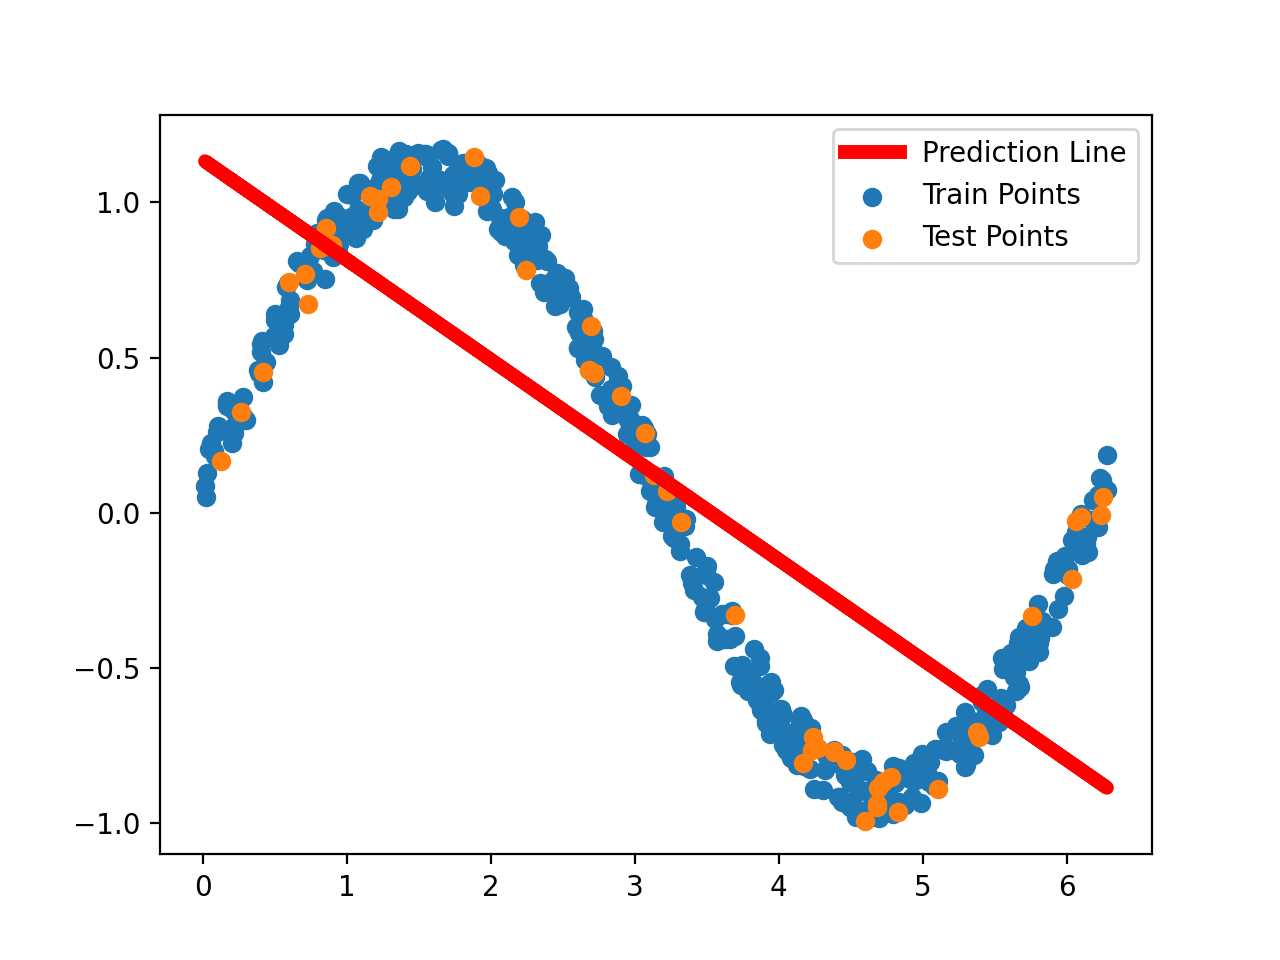

In [9]:
ndims = nl_xTr.shape[1]
linear_model = LinearRegressionModel(ndims)  # initialize the model
linear_model = train_regression_model(nl_xTr, nl_yTr,
                                      linear_model, 
                                      num_epochs=2000, 
                                      lr=1e-2, 
                                      momentum=0.9,
                                      print_freq=500)
avg_test_error = mse_loss(linear_model(nl_xTe), nl_yTe)  # compute the average test error
print('avg test error', avg_test_error.item())

# Visualize the results
plt.figure()
plt.plot(nl_xTr, linear_model(nl_xTr).detach(),linewidth=5.0, color="red", label="Prediction Line")
plt.scatter(nl_xTr, nl_yTr, label="Train Points")
plt.scatter(nl_xTe, nl_yTe, label="Test Points")
plt.legend()
plt.show()

Needless to say, a linear model doesn't model a sine function very well! Let's instead use our first neural network, a __Multi-Layer Perceptron model__. 

We need to define a few layers of the <code>MLPNet</code> using Pytorch, and implement the forward pass. For this network, write an MLP that has:
* Two fully connected layers: Use the Pytorch implementation, <code>nn.Linear(in_dim, out_dim)</code>. This will be updated automatically by Pytorch in our training loop.
* ReLU nonlinearities: Use the Pytorch implementation, <code>nn.functional.relu</code> between each of the linear layers.

In [24]:
# Create a Pytorch Multilayer Perceptron (MLP) Model
#<GRADED>
class MLPNet(nn.Module):
    def __init__(self, input_dim, hidden_dim, output_dim=1):
        super(MLPNet, self).__init__()
        """ pytorch optimizer checks for the properties of the model, and if
            the torch.nn.Parameter requires gradient, then the model will update
            the parameters automatically.
        """
        self.input_dim = input_dim
        
        # Initialize the fully connected layers
#         raise NotImplementedError("Your code goes here!")
        self.fc1 = nn.Linear(input_dim, hidden_dim)
        
        self.fc2 = nn.Linear(hidden_dim, output_dim)
            
    
    def forward(self, x):
        # Implement the forward pass, with ReLU non-linearities
#         raise NotImplementedError("Your code goes here!")
        x = x.view(x.size(0), -1)
        x = self.fc1(x)
        x = F.relu(x)
        x = self.fc2(x)
        
        return x
#</GRADED>

How does the __hidden dimensions__ in an MLP affect the output results? Try out various hidden dimensions using the code provided. We highly recommend for you to play with different number of hidden nodes using the slider tool. Do more or less hidden nodes result in smoother regression outputs? What is the tradeoff?

<IPython.core.display.Javascript object>


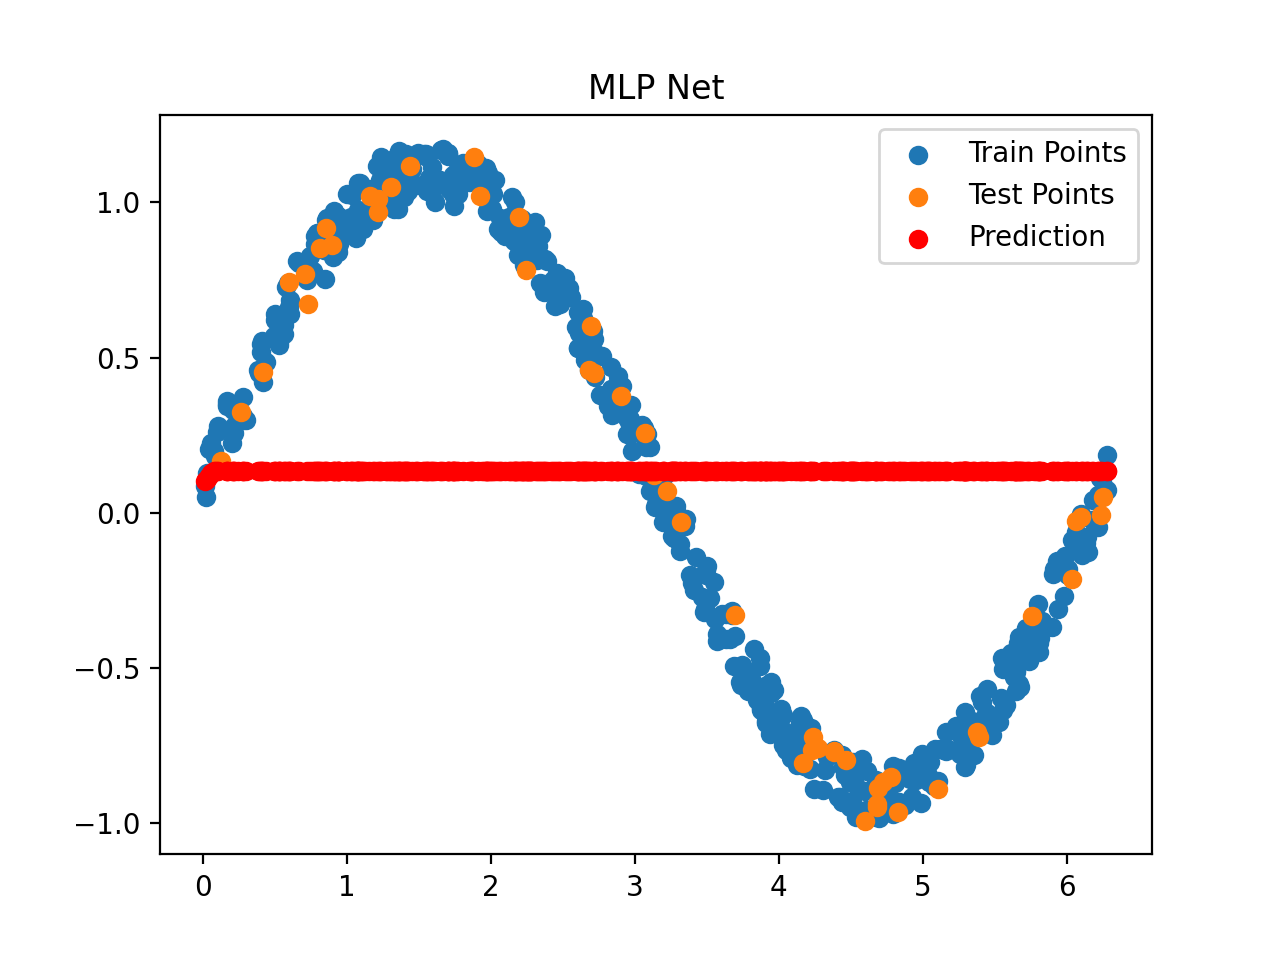

interactive(children=(IntSlider(value=1, description='hdims', min=1), Output()), _dom_classes=('widget-interac…

In [40]:
num_epochs = 2000
lr = 1e-1
momentum = 0.9
trained_models = {}

fig = plt.figure()

def update(hdims):
    fig.clear()
    key = str(hdims)
    if key in trained_models:
        mlp_model = trained_models[key]
    else:
        mlp_model = MLPNet(input_dim=1, hidden_dim=hdims, output_dim=1)
        mlp_model = train_regression_model(nl_xTr, nl_yTr, mlp_model, num_epochs=num_epochs, lr=lr, momentum=momentum, display_loss=False)
        trained_models[key] = mlp_model
    plt.scatter(nl_xTr, nl_yTr, label="Train Points")
    plt.scatter(nl_xTe, nl_yTe, label="Test Points")
    plt.title('MLP Net')
    plt.scatter(nl_xTr, mlp_model(nl_xTr).detach(), color="red", marker='o', label="Prediction")
    plt.legend()
    fig.canvas.draw()

widgets.interact(update, hdims=widgets.IntSlider(value=1, min=1, max=100, step=1));

Run the regression train loop, <code>train_regression_model</code>, with the MLP model on the non-linear data. Use your favorite hidden dimension <code>hdim</code> from above to get the test error below 0.002. Additionally, what learning rates and number of epochs converges for the MLP model? To start, we suggest using <code>num_epochs = 5000</code>, <code>lr = 1e-1</code>, and <code>momentum = 0.9</code>.

In [41]:
hdims = 70
num_epochs = 5000
lr = 1e-1
momentum = 0.9

mlp_model = MLPNet(input_dim=1, hidden_dim=hdims, output_dim=1)
mlp_model = train_regression_model(nl_xTr, nl_yTr, mlp_model, num_epochs=num_epochs, lr=lr, momentum=momentum)
avg_test_error = mse_loss(mlp_model(nl_xTe), nl_yTe)
print('avg test error', avg_test_error.item())

epoch 100 loss 0.05426065996289253
epoch 200 loss 0.03985680267214775
epoch 300 loss 0.029221758246421814
epoch 400 loss 0.02167288400232792
epoch 500 loss 0.016137121245265007
epoch 600 loss 0.012148656882345676
epoch 700 loss 0.009296955540776253
epoch 800 loss 0.0073010120540857315
epoch 900 loss 0.005948147736489773
epoch 1000 loss 0.005011555273085833
epoch 1100 loss 0.0043333121575415134
epoch 1200 loss 0.003829058725386858
epoch 1300 loss 0.0034654121845960617
epoch 1400 loss 0.0031985125970095396
epoch 1500 loss 0.0029943010304123163
epoch 1600 loss 0.002834348240867257
epoch 1700 loss 0.0027037695981562138
epoch 1800 loss 0.0025979611091315746
epoch 1900 loss 0.002513009821996093
epoch 2000 loss 0.002443926176056266
epoch 2100 loss 0.0023856773041188717
epoch 2200 loss 0.00233814911916852
epoch 2300 loss 0.002295754151418805
epoch 2400 loss 0.002258466789498925
epoch 2500 loss 0.00222684140317142
epoch 2600 loss 0.0021999955642968416
epoch 2700 loss 0.0021778657101094723
epoch

Now, we have trained our first neural network model! Let's predict by passing in input data via <code>mlp_model(x)</code>. 

Visualize how good of a fit our MLP is to the data, as compared to the linear model via a side-by-side comparison:

<IPython.core.display.Javascript object>


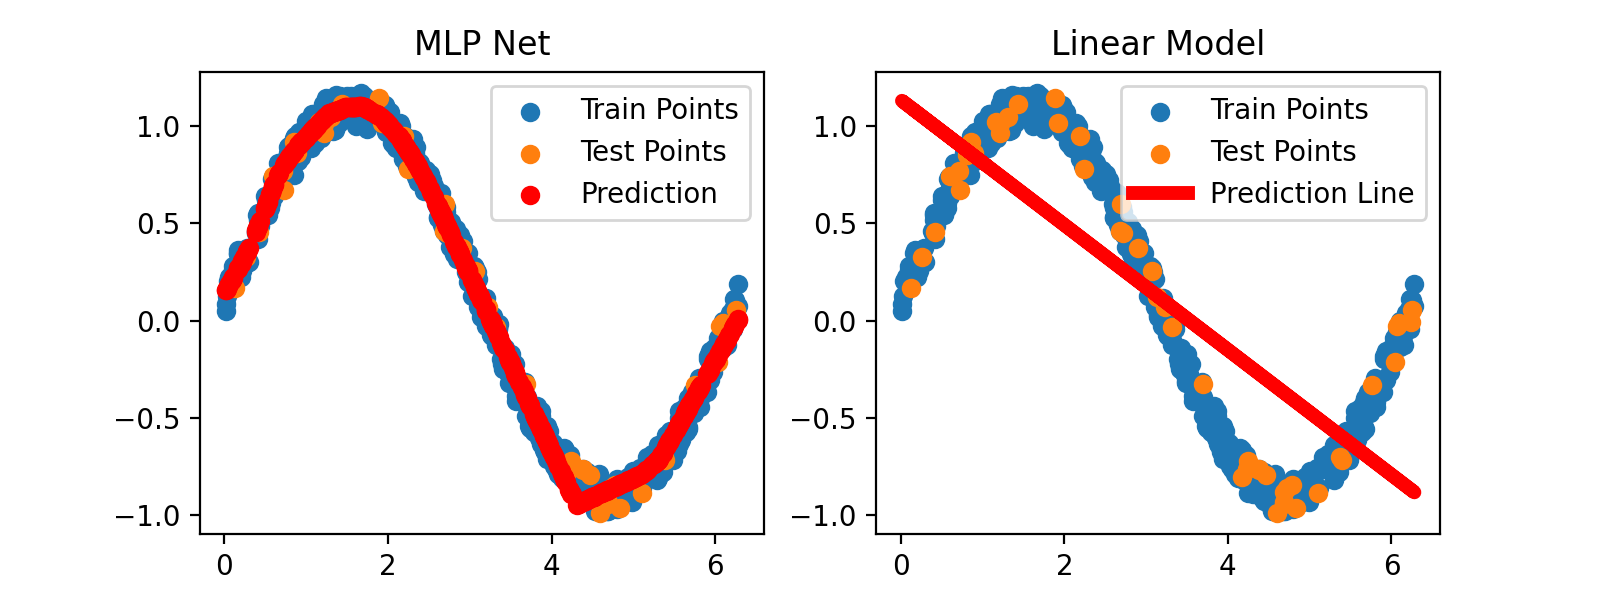

In [42]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(8,3))

# Plot the visualizations from our MLP Model
ax1.scatter(nl_xTr, nl_yTr, label="Train Points")
ax1.scatter(nl_xTe, nl_yTe, label="Test Points")
ax1.scatter(nl_xTr, mlp_model(nl_xTr).detach(), color="red", marker='o', label="Prediction")
ax1.legend()
ax1.set_title('MLP Net')

# Plot the visualizations from our MLP Model
ax2.scatter(nl_xTr, nl_yTr, label="Train Points")
ax2.scatter(nl_xTe, nl_yTe, label="Test Points")
ax2.plot(nl_xTr, linear_model(nl_xTr).detach(),linewidth=5.0, color="red", label="Prediction Line")
ax2.legend()
ax2.set_title('Linear Model')

plt.show()

<h2>Handwritten Digits Classification</h2>

One of the tasks neural network models can solve quite well is classification! We will explore their capabilities on a simple classification task, classifying handwritten digits. Specifically, we will be taking an image of a digit between 0 - 9 and classifying which digit it is.

For this task, we will look into the [MNIST dataset](http://yann.lecun.com/exdb/mnist/). The MNIST database consists of black and white handwritten digits, cropped to a fixed size. It is a good database for people who want to try learning techniques and pattern recognition methods on real-world data while spending minimal efforts on preprocessing and formatting.

Fortunately for us, Pytorch provides an easy implementation to download the cleaned and already prepared data, using a few lines of code. Let us load it and visualize some of the images.

In [43]:
# Load the dataset
trans = transforms.Compose([transforms.ToTensor(), transforms.Normalize((0.5,), (1.0,))])
train_set = dset.MNIST(root=".", train=True, transform=trans, download=True)
# train_subset_indices = np.load("train_subset_indices.npy")  # load a predefined subset for efficiency
# train_set = torch.utils.data.Subset(train_set, train_subset_indices)
test_set = dset.MNIST(root=".", train=False, transform=trans, download=True)

batch_size = 64

train_loader = torch.utils.data.DataLoader(
                 dataset=train_set,
                 batch_size=batch_size,
                 shuffle=True)
test_loader = torch.utils.data.DataLoader(
                dataset=test_set,
                batch_size=batch_size,
                shuffle=False)

<IPython.core.display.Javascript object>


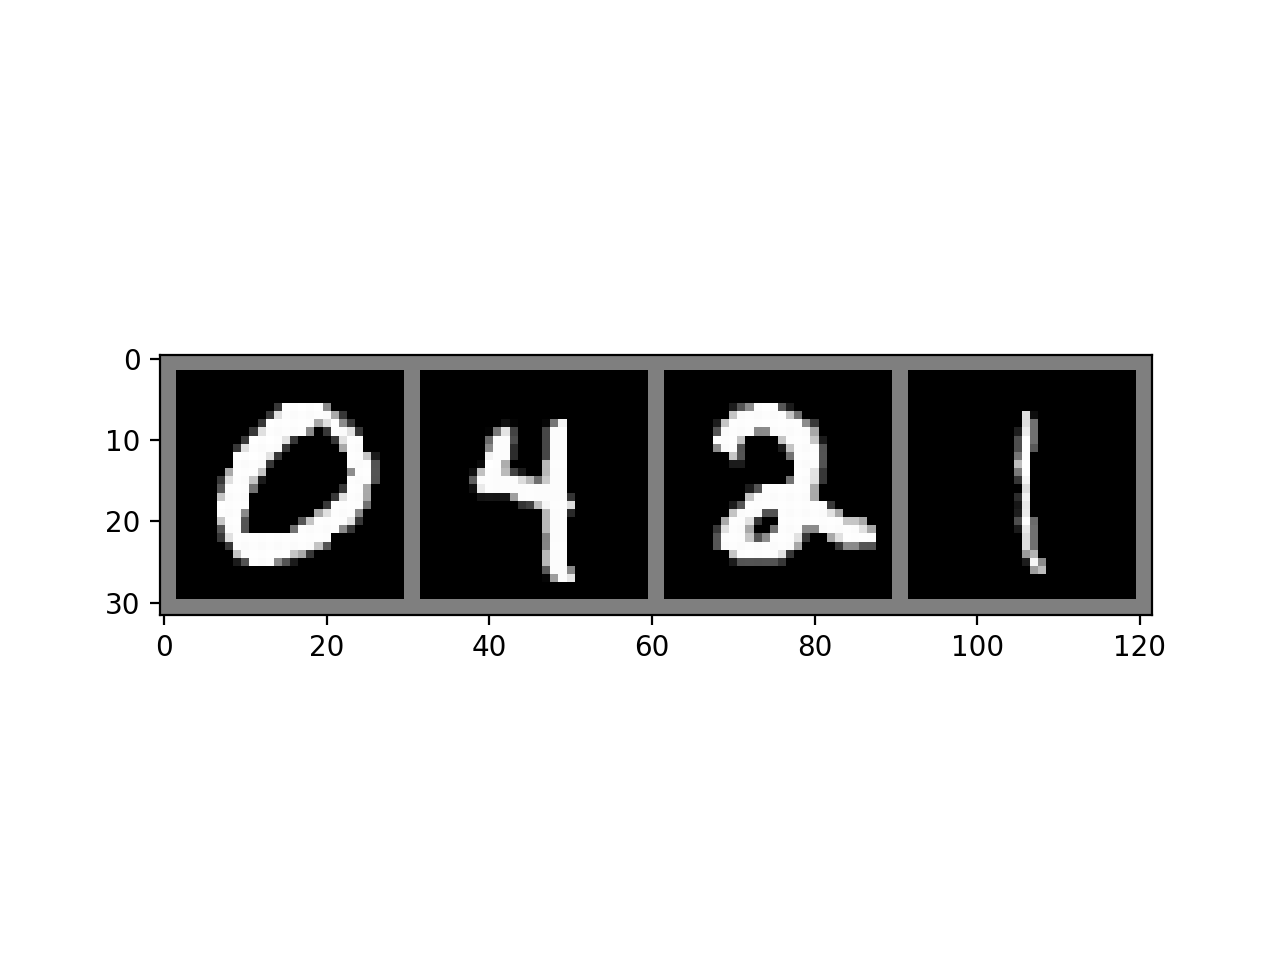

labels are: 0 4 2 1


In [44]:
def imshow(img):
    img = img + 0.5     # unnormalize
    plt.figure()
    plt.imshow(np.transpose(img.numpy(), (1, 2, 0)))
    plt.show()

dataiter = iter(train_loader)
images, labels = next(dataiter)

num_show_img = 4
# show images
imshow(torchvision.utils.make_grid(images[:num_show_img]))
# print labels
print('labels are:', ' '.join('%d' % labels[j] for j in range(num_show_img)))

Update the regression train loop (given above in <code>train_regression_model</code>) to train a classification model instead. The key difference is the loss function used is _no longer the MSE loss_. 

We will instead use the cross entropy loss, which is implemented for us in Pytorch, <code>nn.functional.cross_entropy(predictions, labels)</code>. Implement the new training loop, <code>train_classification_model</code>, and assume that the prediction outputs from the model are in one-hot format. 

In [45]:
# Training function
#<GRADED>
def train_classification_model(train_loader, model, num_epochs, lr=1e-1, momentum=0.9, print_freq=100):
    """Train loop for a neural network model.
    
    Input:
        train_loader:    Data loader for the train set. 
                         Enumerate through to train with each batch.
        model:           nn.Model to be trained
        num_epochs:      number of epochs to train the model for
        lr:              learning rate for the optimizer
        print_freq:      frequency to display the loss
    
    Output:
        model:   nn.Module trained model
    """
    optimizer = CustomSGD(model.parameters(), lr=lr, momentum=momentum)  # create an SGD optimizer for the model parameters
    for epoch in range(num_epochs):
         
        running_loss = 0.0 
        
        # Iterate through the dataloader for each epoch
        for batch_idx, (imgs, labels) in enumerate(train_loader):
            # imgs (torch.Tensor):    batch of input images
            # labels (torch.Tensor):  batch labels corresponding to the inputs
            
            # Implement the training loop using imgs, labels, and cross entropy loss
#             raise NotImplementedError("Your code goes here!")
            optimizer.zero_grad() 
            pred = model(imgs)
            loss = F.cross_entropy(pred, labels)
            loss.backward()
            optimizer.step()
            running_loss += loss.item()
            
        if (epoch + 1) % print_freq == 0:
            avg_loss = running_loss / len(train_loader)
            print(f"Epoch [{epoch+1}/{num_epochs}] - Avg Loss: {avg_loss:.4f}")
            
    return model  # return trained model
#</GRADED>

Additionally, implement the classification test function. Compute the accuracy of our model over the test set. We say that the predicted label is the digit that the model outputs the _maximum score_, and a correct prediction is one where the maximum score matches the true label. Return the average accuracy over all batches in the test set.

In [66]:
# Test function
#<GRADED>
def test_classification_model(test_loader, model):
    """Tests the accuracy of the model.
    
    Input:
        test_loader:      Data loader for the test set. 
                          Enumerate through to test each example.
        model:            nn.Module model being evaluate.
        
    Output:
        accuracy:         Accuracy of the model on the test set.
    """
    # Compute the model accuracy
    
    accuracy = 0
    num_correct = 0
    total = 0
    
    with torch.no_grad():
        for batch_idx, (imgs, labels) in enumerate(test_loader):
#             raise NotImplementedError("Your code goes here!")
#             print(imgs.shape)   # torch.Size([64, 1, 28, 28])
#             print(labels.shape) # torch.Size([64])
#             print(pred.shape) # torch.Size([64, 10])

            pred = model(imgs)
            predicted_labels = torch.argmax(pred, dim=1)

            num_correct += (predicted_labels == labels).sum().item()
            total += labels.size(0)


        accuracy = num_correct / total
    
    return accuracy
#</GRADED>

Finally, we are ready to train an MLP neural network on this classification task! Initialize a <code>MLPNet</code> with the proper input dimension and output dimension. Play around with the hidden dimension to get the accuracy above 95\%. Additionally, what learning rates and number of epochs converges for the MLP model? To start, we suggest using <code>num_epochs = 40</code>, <code>lr = 1e-2</code>, and <code>momentum = 0.9</code>.

In [67]:
# Train an MLP model on MNSIT
hidden_dim = 128
num_epochs = 40
lr = 1e-2
momentum = 0.9

mlp_model = MLPNet(input_dim=28*28, hidden_dim=hidden_dim, output_dim=10)
print('the number of parameters', sum(parameter.view(-1).size()[0] for parameter in mlp_model.parameters()))
mlp_model = train_classification_model(train_loader, mlp_model, num_epochs=num_epochs, lr=lr, momentum=momentum, print_freq=1)
avg_test_acc = test_classification_model(test_loader, mlp_model)
print('avg test accuracy', avg_test_acc)

the number of parameters 101770
Epoch [1/40] - Avg Loss: 1.2434
Epoch [2/40] - Avg Loss: 0.4884
Epoch [3/40] - Avg Loss: 0.3926
Epoch [4/40] - Avg Loss: 0.3552
Epoch [5/40] - Avg Loss: 0.3337
Epoch [6/40] - Avg Loss: 0.3178
Epoch [7/40] - Avg Loss: 0.3046
Epoch [8/40] - Avg Loss: 0.2935
Epoch [9/40] - Avg Loss: 0.2835
Epoch [10/40] - Avg Loss: 0.2738
Epoch [11/40] - Avg Loss: 0.2651
Epoch [12/40] - Avg Loss: 0.2566
Epoch [13/40] - Avg Loss: 0.2483
Epoch [14/40] - Avg Loss: 0.2403
Epoch [15/40] - Avg Loss: 0.2328
Epoch [16/40] - Avg Loss: 0.2259
Epoch [17/40] - Avg Loss: 0.2191
Epoch [18/40] - Avg Loss: 0.2124
Epoch [19/40] - Avg Loss: 0.2067
Epoch [20/40] - Avg Loss: 0.2007
Epoch [21/40] - Avg Loss: 0.1951
Epoch [22/40] - Avg Loss: 0.1897
Epoch [23/40] - Avg Loss: 0.1845
Epoch [24/40] - Avg Loss: 0.1792
Epoch [25/40] - Avg Loss: 0.1746
Epoch [26/40] - Avg Loss: 0.1706
Epoch [27/40] - Avg Loss: 0.1659
Epoch [28/40] - Avg Loss: 0.1617
Epoch [29/40] - Avg Loss: 0.1579
Epoch [30/40] - Avg 

<h3>Convolutional Neural Networks</h3>

In class, we learned about about Convolutional Neural Networks (or CNN for short) that is explicity designed for image inputs. Let's implement and train a CNN on the MNIST dataset!

We need to define a few layers of the <code>ConvNet</code> using Pytorch, and implement the forward pass. For this network, write an CNN that has:
* Two convolutional layers: Use the Pytorch implementation, <code>nn.Conv2d(in_channels, out_channels)</code>. For each convolutional layer, set <code>kernel_size=3</code>, <code>stride=1</code>, <code>padding=1</code> and <code>bias=False</code>.
* ReLU nonlinearities: Use the Pytorch implementation, <code>nn.functional.relu</code> between each of the layers.
* Max-Pooling layers: Use the Pytorch implementation, <code>nn.functional.max_pool2d</code> to pool after each of the ReLU. For each max-pooling layer, set <code>kernel_size=2</code>, <code>stride=2</code>.
* Last layer a fully connected layer: Use the Pytorch implementation, <code>nn.Linear(in_dim, out_dim)</code>. <code>in_dim</code> depends on the size of input image (MNIST images), which is <code>28 * 28</code> in our case. Make sure to re-shape the input into a batch of vectors to pass it through the last layer using the function: <code>Tensor.view(*shape)</code>.

In [70]:
# Create Pytorch ConvNet Model
#<GRADED>
class ConvNet(nn.Module):
    def __init__(self, input_channels=1, hidden_channels=32, output_dim=1):
        super(ConvNet, self).__init__()
        
        # Initialize the ConvNet layers
#         raise NotImplementedError("Your code goes here!")
        self.conv1 = nn.Conv2d(in_channels=input_channels, out_channels=hidden_channels, 
                               kernel_size=3, stride=1, padding=1, bias=False)
        
        self.conv2 = nn.Conv2d(in_channels=hidden_channels, out_channels=hidden_channels, 
                               kernel_size=3, stride=1, padding=1, bias=False)
        
        
        self.fc = nn.Linear(hidden_channels * 7 * 7, output_dim)
        
        
    def forward(self, x):
        # Implement the forward pass, with ReLU non-linearities and max-pooling
#         raise NotImplementedError("Your code goes here!")
        x = self.conv1(x) # 28×28
        x = F.relu(x)
        x = F.max_pool2d(x, kernel_size=2, stride=2) # 14×14
        x = self.conv2(x) # 14×14
        x = F.relu(x)
        x = F.max_pool2d(x, kernel_size=2, stride=2) # 7×7
        x = torch.flatten(x, 1) 
        x = self.fc(x) # should get *7*7 size
        
        return x
#</GRADED>

Run the classificiation train loop, this time with the <code>ConvNet</code> implemented above. Try out different hidden channel dimension to obtain an accuracy above 95\%. (Hint: the channel dimension should not be above 50 for computational efficiency.)

Once again, what learning rates and number of epochs converges for the CNN model? To start, we suggest using <code>num_epochs = 40</code>, <code>lr = 1e-3</code>, and <code>momentum = 0.9</code>.

In [75]:
# Train a convnet model on MNIST
hidden_channels = 32
num_epochs = 40
lr = 1e-3
momentum = 0.9

conv_model = ConvNet(input_channels=1, hidden_channels=hidden_channels, output_dim=10)
print('the number of parameters:', sum(parameter.view(-1).size()[0] for parameter in conv_model.parameters()))
conv_model = train_classification_model(train_loader, conv_model, num_epochs=num_epochs, lr=lr, momentum=momentum, print_freq=1)
avg_test_acc = test_classification_model(test_loader, conv_model)
print('avg test accuracy', avg_test_acc)

the number of parameters: 25194
Epoch [1/40] - Avg Loss: 2.2669
Epoch [2/40] - Avg Loss: 2.1231
Epoch [3/40] - Avg Loss: 1.7026
Epoch [4/40] - Avg Loss: 1.0429
Epoch [5/40] - Avg Loss: 0.6633
Epoch [6/40] - Avg Loss: 0.5079
Epoch [7/40] - Avg Loss: 0.4304
Epoch [8/40] - Avg Loss: 0.3830
Epoch [9/40] - Avg Loss: 0.3504
Epoch [10/40] - Avg Loss: 0.3252
Epoch [11/40] - Avg Loss: 0.3052
Epoch [12/40] - Avg Loss: 0.2884
Epoch [13/40] - Avg Loss: 0.2738
Epoch [14/40] - Avg Loss: 0.2611
Epoch [15/40] - Avg Loss: 0.2496
Epoch [16/40] - Avg Loss: 0.2390
Epoch [17/40] - Avg Loss: 0.2296
Epoch [18/40] - Avg Loss: 0.2211
Epoch [19/40] - Avg Loss: 0.2129
Epoch [20/40] - Avg Loss: 0.2055
Epoch [21/40] - Avg Loss: 0.1986
Epoch [22/40] - Avg Loss: 0.1924
Epoch [23/40] - Avg Loss: 0.1861
Epoch [24/40] - Avg Loss: 0.1807
Epoch [25/40] - Avg Loss: 0.1754
Epoch [26/40] - Avg Loss: 0.1705
Epoch [27/40] - Avg Loss: 0.1657
Epoch [28/40] - Avg Loss: 0.1616
Epoch [29/40] - Avg Loss: 0.1575
Epoch [30/40] - Avg 

<IPython.core.display.Javascript object>


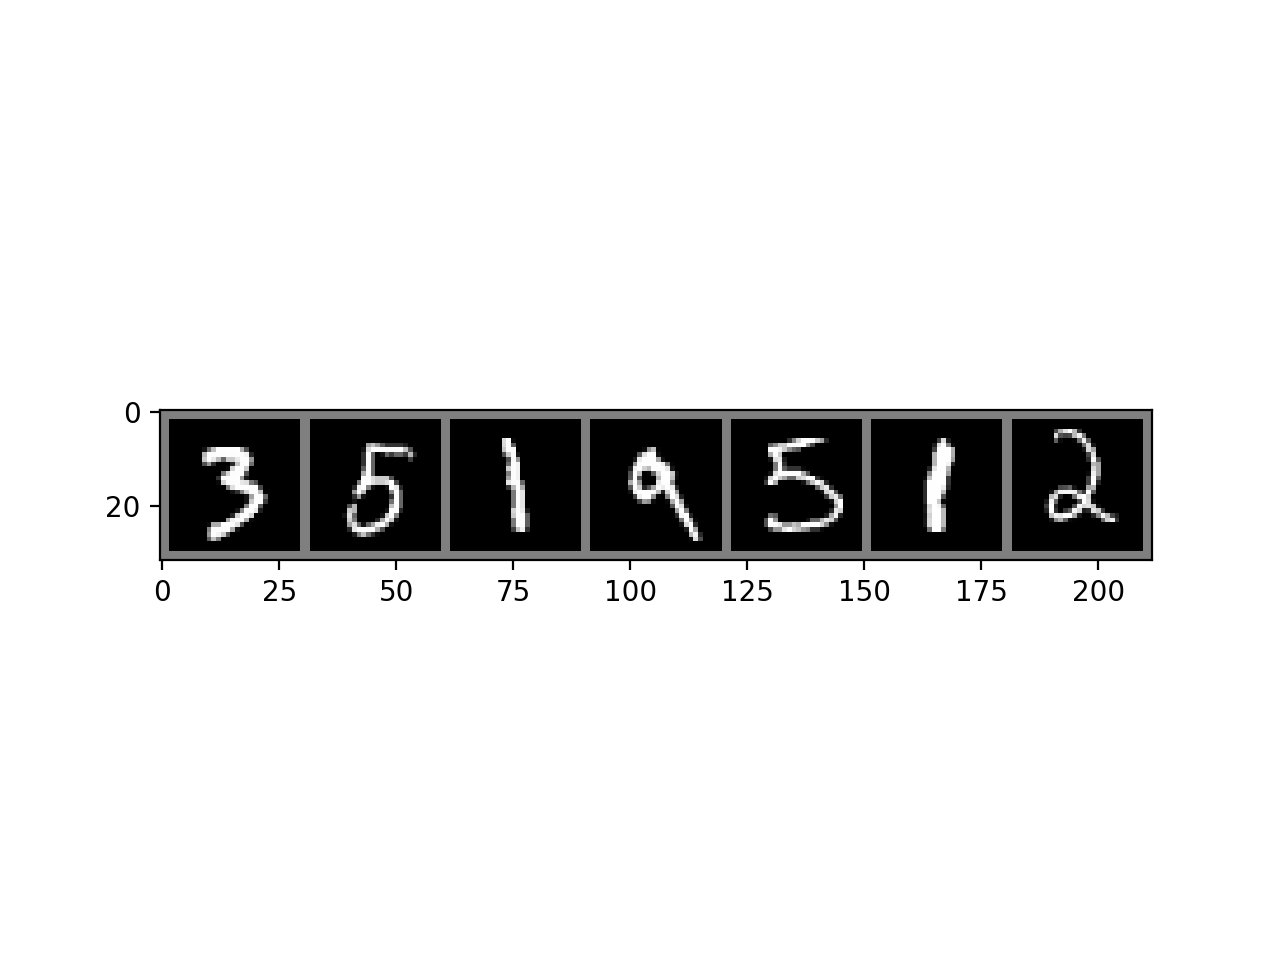

labels are: 3 5 1 9 5 1 2
MLP predictions are: 3 5 1 9 5 1 2
CNN predictions are: 3 5 1 9 5 1 2


In [76]:
dataiter = iter(test_loader)
images, labels = next(dataiter)

# Make a forward pass to get predictions of the MLP model
mlp_scores = mlp_model(images)
_, mlp_preds = torch.max(mlp_scores.data, 1)

# Make a forward pass to get predictions of the ConvNet model
conv_scores = conv_model(images)
_, conv_preds = torch.max(conv_scores.data, 1)

show_img_idx = np.random.randint(images.shape[0], size=7)
# show images
imshow(torchvision.utils.make_grid(images[show_img_idx]))
# print labels
print('labels are:', ' '.join('%d' % labels[j] for j in show_img_idx))
# print predictions
print('MLP predictions are:', ' '.join('%d' % mlp_preds[j] for j in show_img_idx))
print('CNN predictions are:', ' '.join('%d' % conv_preds[j] for j in show_img_idx))

<h3>Why Do CNN's Work?</h3>

Let's try to build some intuition behind why Convolution Neural Networks work well for image inputs.

For a toy experiment, let's shuffle the pixels for each of the input images, _but only in a set order_. Would we expect to see ConvNet's still working better than MLP?

In [77]:
# Load the shuffled dataset
torch.manual_seed(0)
trans = transforms.Compose([transforms.ToTensor(), transforms.Normalize((0.5,), (1.0,))])
pixel_shuffle_train_set = dset.MNIST(root=".", train=True, transform=trans, download=True)
train_subset_indices = np.load("train_subset_indices.npy")  # load a subset for efficiency
pixel_shuffle_train_set = torch.utils.data.Subset(pixel_shuffle_train_set, train_subset_indices)
pixel_shuffle_test_set = dset.MNIST(root=".", train=False, transform=trans, download=True)

randperm = torch.randperm(28 * 28)
pixel_shuffle_train_set.dataset.data = pixel_shuffle_train_set.dataset.data.view(-1, 28 * 28)[:, randperm].view(-1, 28, 28)
pixel_shuffle_test_set.data = pixel_shuffle_test_set.data.view(-1, 28 * 28)[:, randperm].view(-1, 28, 28)

batch_size = 64
pixel_shuffle_train_loader = torch.utils.data.DataLoader(
                 dataset=pixel_shuffle_train_set,
                 batch_size=batch_size,
                 shuffle=True)
pixel_shuffle_test_loader = torch.utils.data.DataLoader(
                dataset=pixel_shuffle_test_set,
                batch_size=batch_size,
                shuffle=False)

<IPython.core.display.Javascript object>


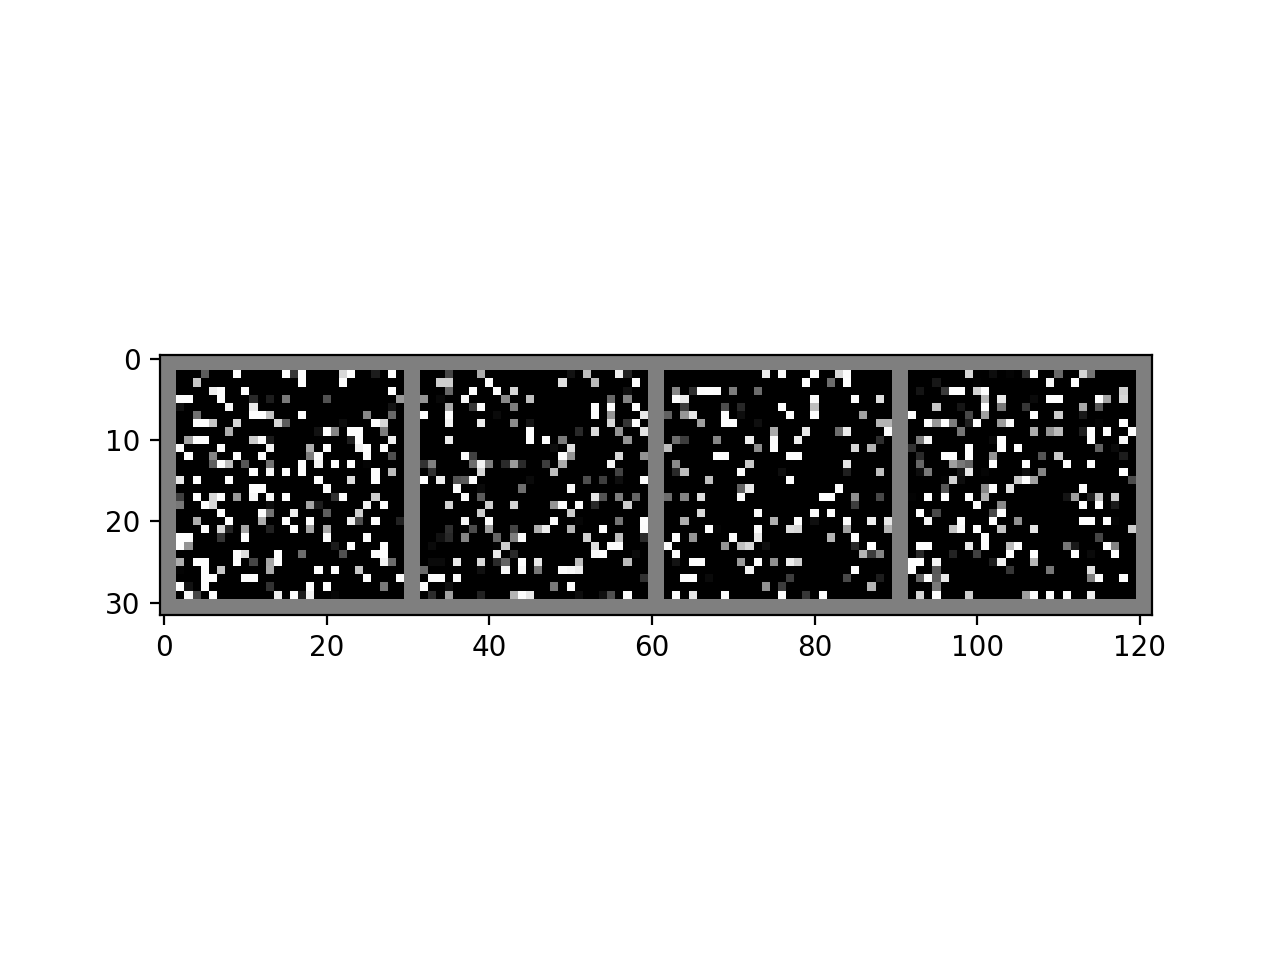

labels are: 2 0 8 9


In [78]:
dataiter = iter(pixel_shuffle_train_loader)
images, labels = next(dataiter)

num_show_img = 4
# show shuffled images
imshow(torchvision.utils.make_grid(images[:num_show_img]))
# print labels
print('labels are:', ' '.join('%d' % labels[j] for j in range(num_show_img)))

It looks like kind of a mess! But let's train an MLP model anyways, as before, and observe the new test accuracy on this shuffled-pixel dataset. __Use the same hyperparameters as you did before__.

In [81]:
# Train an MLP model on pixel-shuffled MNSIT
hidden_dim = 32
num_epochs = 40
lr = 1e-3
momentum = 0.9

mlp_model = MLPNet(input_dim=28*28, hidden_dim=hidden_dim, output_dim=10)
print('the number of parameters:', sum(parameter.view(-1).size()[0] for parameter in mlp_model.parameters()))
mlp_model = train_classification_model(pixel_shuffle_train_loader, mlp_model, num_epochs=num_epochs, lr=lr, momentum=momentum, print_freq=1)
avg_test_acc = test_classification_model(pixel_shuffle_test_loader, mlp_model)
print('avg test accuracy', avg_test_acc)

the number of parameters: 25450
Epoch [1/40] - Avg Loss: 2.2917
Epoch [2/40] - Avg Loss: 2.2576
Epoch [3/40] - Avg Loss: 2.2286
Epoch [4/40] - Avg Loss: 2.1983
Epoch [5/40] - Avg Loss: 2.1677
Epoch [6/40] - Avg Loss: 2.1358
Epoch [7/40] - Avg Loss: 2.1025
Epoch [8/40] - Avg Loss: 2.0673
Epoch [9/40] - Avg Loss: 2.0309
Epoch [10/40] - Avg Loss: 1.9921
Epoch [11/40] - Avg Loss: 1.9523
Epoch [12/40] - Avg Loss: 1.9102
Epoch [13/40] - Avg Loss: 1.8665
Epoch [14/40] - Avg Loss: 1.8216
Epoch [15/40] - Avg Loss: 1.7746
Epoch [16/40] - Avg Loss: 1.7259
Epoch [17/40] - Avg Loss: 1.6775
Epoch [18/40] - Avg Loss: 1.6287
Epoch [19/40] - Avg Loss: 1.5791
Epoch [20/40] - Avg Loss: 1.5290
Epoch [21/40] - Avg Loss: 1.4808
Epoch [22/40] - Avg Loss: 1.4331
Epoch [23/40] - Avg Loss: 1.3867
Epoch [24/40] - Avg Loss: 1.3404
Epoch [25/40] - Avg Loss: 1.2969
Epoch [26/40] - Avg Loss: 1.2561
Epoch [27/40] - Avg Loss: 1.2156
Epoch [28/40] - Avg Loss: 1.1779
Epoch [29/40] - Avg Loss: 1.1438
Epoch [30/40] - Avg 

Additionally, train a CNN model, as before, and observe the new test accuracy on this shuffled-pixel dataset. __Use the same hyperparameters as you did before__.

In [82]:
# Train a ConvNet model on pixel-shuffled MNSIT
hidden_channels = 32
num_epochs = 40
lr = 1e-3
momentum = 0.9
conv_model = ConvNet(input_channels=1, hidden_channels=hidden_channels, output_dim=10)
print('the number of parameters:', sum(parameter.view(-1).size()[0] for parameter in conv_model.parameters()))
conv_model = train_classification_model(pixel_shuffle_train_loader, conv_model, num_epochs=num_epochs, lr=lr, momentum=momentum, print_freq=1)
avg_test_acc = test_classification_model(pixel_shuffle_test_loader, conv_model)
print('avg test accuracy', avg_test_acc)

the number of parameters: 25194
Epoch [1/40] - Avg Loss: 2.3041
Epoch [2/40] - Avg Loss: 2.2956
Epoch [3/40] - Avg Loss: 2.2888
Epoch [4/40] - Avg Loss: 2.2821
Epoch [5/40] - Avg Loss: 2.2751
Epoch [6/40] - Avg Loss: 2.2680
Epoch [7/40] - Avg Loss: 2.2603
Epoch [8/40] - Avg Loss: 2.2523
Epoch [9/40] - Avg Loss: 2.2437
Epoch [10/40] - Avg Loss: 2.2346
Epoch [11/40] - Avg Loss: 2.2244
Epoch [12/40] - Avg Loss: 2.2135
Epoch [13/40] - Avg Loss: 2.2019
Epoch [14/40] - Avg Loss: 2.1888
Epoch [15/40] - Avg Loss: 2.1747
Epoch [16/40] - Avg Loss: 2.1597
Epoch [17/40] - Avg Loss: 2.1429
Epoch [18/40] - Avg Loss: 2.1250
Epoch [19/40] - Avg Loss: 2.1052
Epoch [20/40] - Avg Loss: 2.0837
Epoch [21/40] - Avg Loss: 2.0611
Epoch [22/40] - Avg Loss: 2.0367
Epoch [23/40] - Avg Loss: 2.0114
Epoch [24/40] - Avg Loss: 1.9841
Epoch [25/40] - Avg Loss: 1.9567
Epoch [26/40] - Avg Loss: 1.9271
Epoch [27/40] - Avg Loss: 1.8981
Epoch [28/40] - Avg Loss: 1.8684
Epoch [29/40] - Avg Loss: 1.8389
Epoch [30/40] - Avg 

Observe that the accuracy is now _slightly lower than_ that of MLP models! This shows that CNN's utilize the stucture of the image (i.e., pixel proximity) to make their predictions. With the pixel orders shuffled, it is no longer as good of a model.

Let us visualize some of the prediction results.

<IPython.core.display.Javascript object>


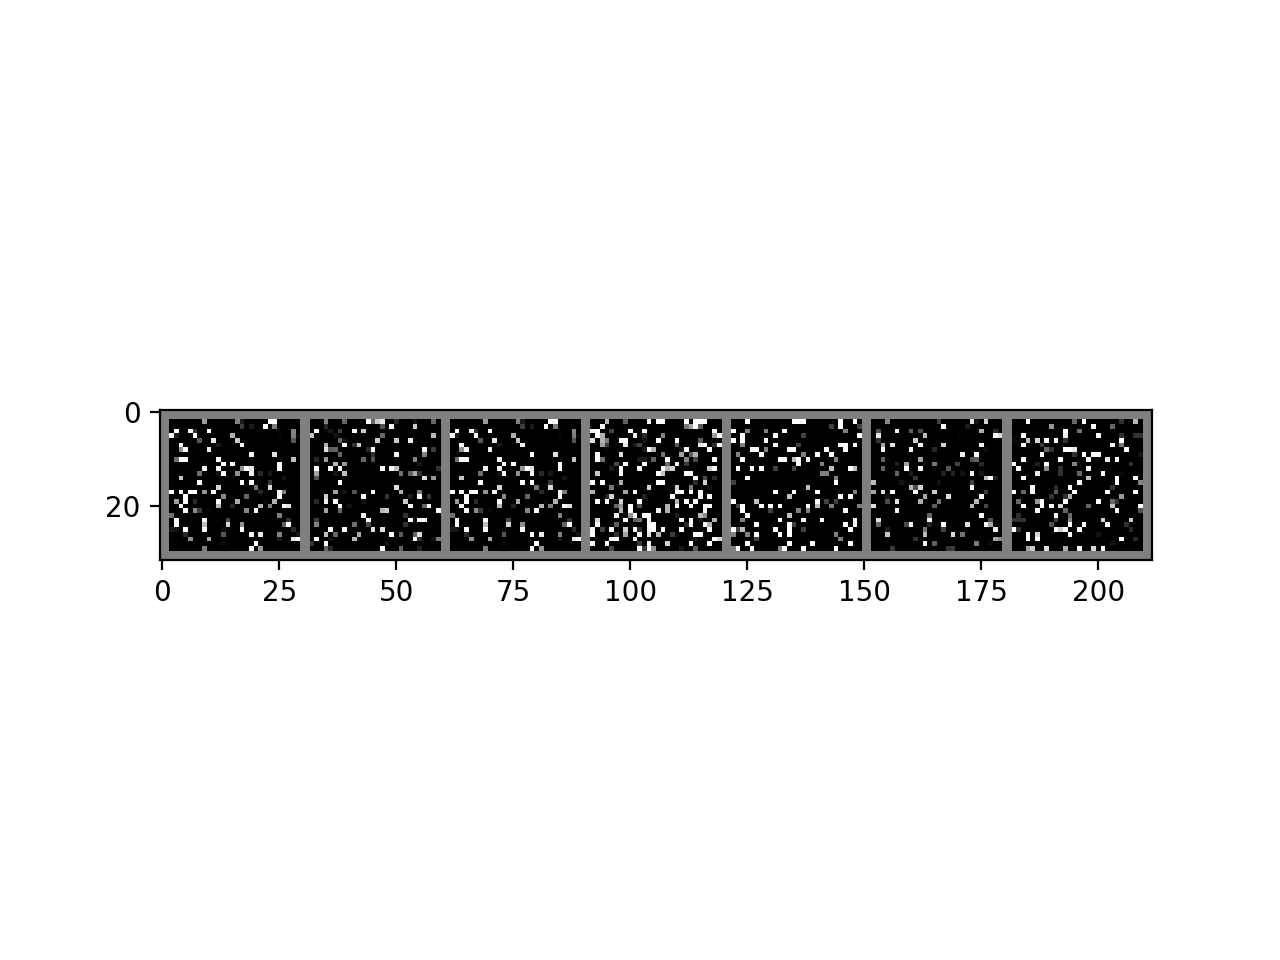

labels are: 3 5 3 3 7 2 4
MLP predictions are: 2 5 2 3 7 2 4
CNN predictions are: 4 5 4 3 7 4 4


In [83]:
dataiter = iter(pixel_shuffle_test_loader)
images, labels = next(dataiter)

# Make a forward pass to get predictions of the MLP model
mlp_scores = mlp_model(images)
_, mlp_preds = torch.max(mlp_scores.data, 1)

# Make a forward pass to get predictions of the ConvNet model
conv_scores = conv_model(images)
_, conv_preds = torch.max(conv_scores.data, 1)

show_img_idx = np.random.randint(images.shape[0], size=7)
# show images
imshow(torchvision.utils.make_grid(images[show_img_idx]))
# print labels
print('labels are:', ' '.join('%d' % labels[j] for j in show_img_idx))
# print predictions
print('MLP predictions are:', ' '.join('%d' % mlp_preds[j] for j in show_img_idx))
print('CNN predictions are:', ' '.join('%d' % conv_preds[j] for j in show_img_idx))

# GenAI
You must disclose and describe any use of GenAI in this project. You are allowed to use SAI.
You are also allowed to use other GenAI tools, but you are not allowed to post any text that
you did not write yourself (i.e., anything in this notebook template). Think of the GenAI as a
TA who can help you with its knowledge of python, but who should not do the ML for you.
If you use any GenAI, please paste the interaction below: